<a href="https://colab.research.google.com/github/darine-com/low-code-book-projects/blob/main/Churn_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/Churn_Modelling.csv')

In [3]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()

# Display missing values count for each column
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64


In [4]:
# Remove rows with missing values
df_cleaned = df.dropna()

# Display the shape of the cleaned dataset
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")


Original dataset shape: (10002, 14)
Cleaned dataset shape: (9998, 14)


In [5]:
# Remove rows with missing values
df_cleaned = df.dropna()

# Display the shape of the cleaned dataset
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

# Display the first few rows of the cleaned dataset
df_cleaned.head()


Original dataset shape: (10002, 14)
Cleaned dataset shape: (9998, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,6,15574012,Chu,645,Spain,Male,44.0,8,113755.78,2,1.0,0.0,149756.71,1


In [6]:
# Check for duplicates in the dataset
duplicates = df_cleaned[df_cleaned.duplicated()]

# Display the number of duplicate rows
print(f"Number of duplicate rows: {duplicates.shape[0]}")

# Display the first few duplicate rows (if any)
duplicates.head()


Number of duplicate rows: 2


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9999,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1.0,0.0,92888.52,1
10001,10000,15628319,Walker,792,France,Female,28.0,4,130142.79,1,1.0,0.0,38190.78,0


In [7]:
# Remove duplicate rows from the dataset
df_cleaned_no_duplicates = df_cleaned.drop_duplicates()

# Display the shape of the dataset after removing duplicates
print(f"Dataset shape after removing duplicates: {df_cleaned_no_duplicates.shape}")

# Display the first few rows of the cleaned dataset
df_cleaned_no_duplicates.head()


Dataset shape after removing duplicates: (9996, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,6,15574012,Chu,645,Spain,Male,44.0,8,113755.78,2,1.0,0.0,149756.71,1


In [8]:
# Get basic descriptive statistics for numeric columns
descriptive_stats = df_cleaned_no_duplicates.describe()

# Display the descriptive statistics
print("Descriptive Statistics for Numeric Columns:")
print(descriptive_stats)


Descriptive Statistics for Numeric Columns:
          RowNumber    CustomerId  CreditScore          Age       Tenure  \
count   9996.000000  9.996000e+03  9996.000000  9996.000000  9996.000000   
mean    5002.497899  1.569095e+07   650.503301    38.921071     5.013305   
std     2885.744618  7.192840e+04    96.624668    10.488421     2.892353   
min        1.000000  1.556570e+07   350.000000    18.000000     0.000000   
25%     2503.750000  1.562855e+07   584.000000    32.000000     3.000000   
50%     5002.500000  1.569074e+07   652.000000    37.000000     5.000000   
75%     7501.250000  1.575323e+07   717.250000    44.000000     7.250000   
max    10000.000000  1.581569e+07   850.000000    92.000000    10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count    9996.000000    9996.000000  9996.000000     9996.000000   
mean    76476.263216       1.530212     0.705482        0.514906   
std     62397.118820       0.581684     0.455849        0.499803   

Basic Statistics for Balance Column:
count     10002.000000
mean      76491.112875
std       62393.474144
min           0.000000
25%           0.000000
50%       97198.540000
75%      127647.840000
max      250898.090000
Name: Balance, dtype: float64

Outlier Thresholds:
Lower Bound: -191471.76
Upper Bound: 319119.6

Number of Outliers: 0


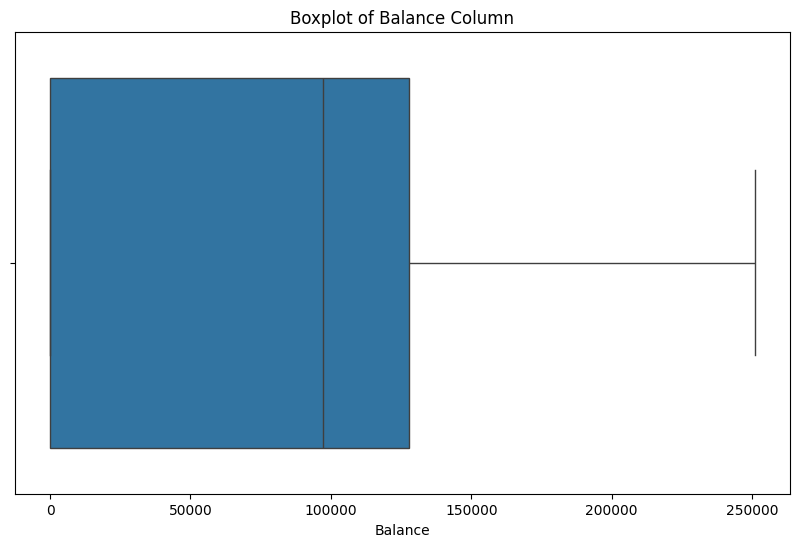

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check basic statistics for the Balance column
balance_stats = df['Balance'].describe()
print("Basic Statistics for Balance Column:")
print(balance_stats)

# Identify potential outliers using the Interquartile Range (IQR) method
Q1 = df['Balance'].quantile(0.25)
Q3 = df['Balance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nOutlier Thresholds:")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Filter rows with outliers
outliers = df[(df['Balance'] < lower_bound) | (df['Balance'] > upper_bound)]
print(f"\nNumber of Outliers: {len(outliers)}")

# Visualize the Balance column with a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Balance'])
plt.title("Boxplot of Balance Column")
plt.show()


In [10]:
# Calculate min, max, and average age
min_Age = df_cleaned_no_duplicates['Age'].min()
max_Age = df_cleaned_no_duplicates['Age'].max()
avg_Age = df_cleaned_no_duplicates['Age'].mean()

# Print the results
print(f"Minimum Age: {min_Age}")
print(f"Maximum Age: {max_Age}")
print(f"Average Age: {avg_Age}")

Minimum Age: 18.0
Maximum Age: 92.0
Average Age: 38.92107142857143


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Select columns to scale
columns_to_scale = ['Age', 'CreditScore', 'Balance']

# Apply Min-Max scaling to the selected columns
df_cleaned[columns_to_scale] = scaler.fit_transform(df_cleaned[columns_to_scale])

# Display the first few rows to verify the results
print("Min-Max Scaling applied to Age, CreditScore, and Balance columns:")
df_cleaned[columns_to_scale].head()


Min-Max Scaling applied to Age, CreditScore, and Balance columns:


<ipython-input-11-9c6e4ab917e2>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[columns_to_scale] = scaler.fit_transform(df_cleaned[columns_to_scale])


,Age,CreditScore,Balance
0,0.324324,0.538,0.000000
1,0.310811,0.516,0.334031
2,0.324324,0.304,0.636357
3,0.283784,0.698,0.000000
5,0.351351,0.590,0.453394


In [12]:
# Avoid division by zero by replacing Tenure values of 0 with 1
df_cleaned['Tenure_Adjusted'] = df_cleaned['Tenure'].replace(0, 1)

# Calculate the Tenure-to-Balance Ratio
df_cleaned['Tenure_Balance_Ratio'] = df_cleaned['Balance'] / df_cleaned['Tenure_Adjusted']

# Drop the temporary column 'Tenure_Adjusted' (optional, if not needed further)
df_cleaned.drop(columns=['Tenure_Adjusted'], inplace=True)

# Display the first few rows to verify the results
print("Tenure-to-Balance Ratio added:")
df_cleaned[['Tenure', 'Balance', 'Tenure_Balance_Ratio']].head(10)


Tenure-to-Balance Ratio added:


<ipython-input-12-40f3aaf0ba67>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Tenure_Adjusted'] = df_cleaned['Tenure'].replace(0, 1)
<ipython-input-12-40f3aaf0ba67>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Tenure_Balance_Ratio'] = df_cleaned['Balance'] / df_cleaned['Tenure_Adjusted']
<ipython-input-12-40f3aaf0ba67>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/p

,Tenure,Balance,Tenure_Balance_Ratio
0,2,0.000000,0.000000
1,1,0.334031,0.334031
2,8,0.636357,0.079545
3,1,0.000000,0.000000
5,8,0.453394,0.056674
7,4,0.458540,0.114635
10,6,0.406606,0.067768
11,3,0.000000,0.000000
12,10,0.000000,0.000000
13,5,0.000000,0.000000


In [13]:
# List of numerical features to analyze
numerical_features = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Tenure_Balance_Ratio']

# Define bins for each feature (adjust bins as needed for each feature)
bin_ranges = {
    'Age': range(0, 101, 10),  # Bins for Age (0-10, 10-20, ..., 90-100)
    'CreditScore': range(300, 901, 50),  # Bins for CreditScore (300-350, ..., 850-900)
    'Balance': range(0, 260001, 50000),  # Bins for Balance (0-50k, ..., 250k+)
    'EstimatedSalary': range(0, 201001, 50000),  # Bins for Salary (0-50k, ..., 200k+)
    'Tenure_Balance_Ratio': [0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 10]  # Custom bins for the ratio
}

# Create a table for each feature's distribution
distribution_tables = {}
for feature in numerical_features:
    bins = bin_ranges[feature]
    df_cleaned[f'{feature}_bin'] = pd.cut(df_cleaned[feature], bins=bins, include_lowest=True)
    distribution = df_cleaned[f'{feature}_bin'].value_counts().sort_index().reset_index()
    distribution.columns = ['Range', 'Count']
    distribution_tables[feature] = distribution

# Display the distribution tables
for feature, table in distribution_tables.items():
    print(f"Distribution for {feature}:")
    print(table)
    print("\n")


Distribution for Age:
            Range  Count
0  (-0.001, 10.0]   9998
1    (10.0, 20.0]      0
2    (20.0, 30.0]      0
3    (30.0, 40.0]      0
4    (40.0, 50.0]      0
5    (50.0, 60.0]      0
6    (60.0, 70.0]      0
7    (70.0, 80.0]      0
8    (80.0, 90.0]      0
9   (90.0, 100.0]      0


Distribution for CreditScore:
               Range  Count
0   (299.999, 350.0]      0
1     (350.0, 400.0]      0
2     (400.0, 450.0]      0
3     (450.0, 500.0]      0
4     (500.0, 550.0]      0
5     (550.0, 600.0]      0
6     (600.0, 650.0]      0
7     (650.0, 700.0]      0
8     (700.0, 750.0]      0
9     (750.0, 800.0]      0
10    (800.0, 850.0]      0
11    (850.0, 900.0]      0


Distribution for Balance:
                  Range  Count
0     (-0.001, 50000.0]   9998
1   (50000.0, 100000.0]      0
2  (100000.0, 150000.0]      0
3  (150000.0, 200000.0]      0
4  (200000.0, 250000.0]      0


Distribution for EstimatedSalary:
                  Range  Count
0     (-0.001, 50000.0]   

<ipython-input-13-620ccbb58147>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[f'{feature}_bin'] = pd.cut(df_cleaned[feature], bins=bins, include_lowest=True)
<ipython-input-13-620ccbb58147>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[f'{feature}_bin'] = pd.cut(df_cleaned[feature], bins=bins, include_lowest=True)
<ipython-input-13-620ccbb58147>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [14]:
# List of numerical features to analyze
numerical_features = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Tenure_Balance_Ratio']

# Define bins for each feature (adjust bins as needed for each feature)
bin_ranges = {
    'Age': range(0, 101, 10),  # Bins for Age (0-10, 10-20, ..., 90-100)
    'CreditScore': range(300, 901, 50),  # Bins for CreditScore (300-350, ..., 850-900)
    'Balance': range(0, 260001, 50000),  # Bins for Balance (0-50k, ..., 250k+)
    'EstimatedSalary': range(0, 201001, 50000),  # Bins for Salary (0-50k, ..., 200k+)
    'Tenure_Balance_Ratio': [0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 10]  # Custom bins for the ratio
}

# Create a combined distribution table
combined_distribution = pd.DataFrame()

for feature in numerical_features:
    bins = bin_ranges[feature]
    df_cleaned[f'{feature}_bin'] = pd.cut(df_cleaned[feature], bins=bins, include_lowest=True)
    distribution = df_cleaned[f'{feature}_bin'].value_counts().sort_index().reset_index()
    distribution.columns = ['Range', f'{feature}_Count']

    if combined_distribution.empty:
        combined_distribution['Range'] = distribution['Range']

    combined_distribution = pd.merge(combined_distribution, distribution, on='Range', how='outer')

# Fill missing values with 0 for ranges that do not exist in some features
combined_distribution = combined_distribution.fillna(0)

# Display the combined distribution table
print("Combined Distribution Table:")
print(combined_distribution)


Combined Distribution Table:
                   Range  Age_Count  CreditScore_Count  Balance_Count  \
0         (-0.001, 10.0]     9998.0                0.0            0.0   
1      (-0.001, 50000.0]        0.0                0.0         9998.0   
2           (10.0, 20.0]        0.0                0.0            0.0   
3           (20.0, 30.0]        0.0                0.0            0.0   
4           (30.0, 40.0]        0.0                0.0            0.0   
5           (40.0, 50.0]        0.0                0.0            0.0   
6           (50.0, 60.0]        0.0                0.0            0.0   
7           (60.0, 70.0]        0.0                0.0            0.0   
8           (70.0, 80.0]        0.0                0.0            0.0   
9           (80.0, 90.0]        0.0                0.0            0.0   
10         (90.0, 100.0]        0.0                0.0            0.0   
11      (299.999, 350.0]        0.0                0.0            0.0   
12        (350.0, 400.

<ipython-input-14-4c2f4fd5bd4b>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[f'{feature}_bin'] = pd.cut(df_cleaned[feature], bins=bins, include_lowest=True)
<ipython-input-14-4c2f4fd5bd4b>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[f'{feature}_bin'] = pd.cut(df_cleaned[feature], bins=bins, include_lowest=True)
<ipython-input-14-4c2f4fd5bd4b>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [15]:
# Calculate statistics for each column
statistics = {
    'Min_Age': df_cleaned['Age'].min(),
    'Max_Age': df_cleaned['Age'].max(),
    'Avg_Age': df_cleaned['Age'].mean(),
    'StdDev_Age': df_cleaned['Age'].std(),

    'Min_Balance': df_cleaned['Balance'].min(),
    'Max_Balance': df_cleaned['Balance'].max(),
    'Avg_Balance': df_cleaned['Balance'].mean(),
    'StdDev_Balance': df_cleaned['Balance'].std(),

    'Min_Tenure': df_cleaned['Tenure'].min(),
    'Max_Tenure': df_cleaned['Tenure'].max(),
    'Avg_Tenure': df_cleaned['Tenure'].mean(),
    'StdDev_Tenure': df_cleaned['Tenure'].std(),

    'Min_NumOfProducts': df_cleaned['NumOfProducts'].min(),
    'Max_NumOfProducts': df_cleaned['NumOfProducts'].max(),
    'Avg_NumOfProducts': df_cleaned['NumOfProducts'].mean(),
    'StdDev_NumOfProducts': df_cleaned['NumOfProducts'].std(),

    'Min_EstimatedSalary': df_cleaned['EstimatedSalary'].min(),
    'Max_EstimatedSalary': df_cleaned['EstimatedSalary'].max(),
    'Avg_EstimatedSalary': df_cleaned['EstimatedSalary'].mean(),
    'StdDev_EstimatedSalary': df_cleaned['EstimatedSalary'].std()
}

# Convert the statistics dictionary into a DataFrame for better readability
stats_df = pd.DataFrame(statistics, index=[0])

# Display the statistics
print(stats_df)


   Min_Age  Max_Age   Avg_Age  StdDev_Age  Min_Balance  Max_Balance  \
0      0.0      1.0  0.282707     0.14173          0.0          1.0   

   Avg_Balance  StdDev_Balance  Min_Tenure  Max_Tenure  Avg_Tenure  \
0     0.304831        0.248679           0          10    5.013003   

   StdDev_Tenure  Min_NumOfProducts  Max_NumOfProducts  Avg_NumOfProducts  \
0       2.892152                  1                  4           1.530206   

   StdDev_NumOfProducts  Min_EstimatedSalary  Max_EstimatedSalary  \
0              0.581669                11.58            199992.48   

   Avg_EstimatedSalary  StdDev_EstimatedSalary  
0        100099.786455            57510.939962  


In [16]:
import pandas as pd
import numpy as np

# Assuming df_cleaned is already loaded in Google Colab
# Calculate the mean and standard deviation for each column
means = df_cleaned[['Age', 'Balance', 'Tenure', 'NumOfProducts', 'EstimatedSalary']].mean()
std_devs = df_cleaned[['Age', 'Balance', 'Tenure', 'NumOfProducts', 'EstimatedSalary']].std()

# Calculate covariance between pairs of features
cov_matrix = df_cleaned[['Age', 'Balance', 'Tenure', 'NumOfProducts', 'EstimatedSalary']].cov()

# Convert std_devs to a NumPy array and reshape for broadcasting
std_devs_array = np.array(std_devs)

# Calculate correlation matrix using the covariance and standard deviations
correlation_matrix = cov_matrix / (std_devs_array[:, None] * std_devs_array)

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                      Age   Balance    Tenure  NumOfProducts  EstimatedSalary
Age              1.000000  0.028376 -0.010116      -0.030762        -0.006939
Balance          0.028376  1.000000 -0.011986      -0.304163         0.012637
Tenure          -0.010116 -0.011986  1.000000       0.013205         0.007835
NumOfProducts   -0.030762 -0.304163  0.013205       1.000000         0.014378
EstimatedSalary -0.006939  0.012637  0.007835       0.014378         1.000000


In [17]:
import pandas as pd

# Assuming df_cleaned is already loaded in Google Colab

# 1. Check for missing values in critical columns
missing_values = {
    'Missing_CreditScore': df_cleaned['CreditScore'].isnull().sum(),
    'Missing_Exited': df_cleaned['Exited'].isnull().sum(),
    'Missing_CustomerId': df_cleaned['CustomerId'].isnull().sum()
}

# 2. Check for duplicates based on CustomerId
unique_customer_count = df_cleaned['CustomerId'].nunique()
total_row_count = len(df_cleaned)

# Check for duplicates based on CustomerId
duplicates_customer_id = df_cleaned.duplicated(subset=['CustomerId']).sum()

# 3. Summary statistics for key numerical columns (e.g., Age)
age_summary = {
    'Min_Age': df_cleaned['Age'].min(),
    'Max_Age': df_cleaned['Age'].max(),
    'Average_Age': df_cleaned['Age'].mean(),
    'StdDev_Age': df_cleaned['Age'].std()
}

# 4. Verify if columns exist (CreditScore and Exited)
columns_exist = {
    'CreditScore_Column_Exists': 'CreditScore' in df_cleaned.columns,
    'Exited_Column_Exists': 'Exited' in df_cleaned.columns
}

# Display all results
print("Missing Values:", missing_values)
print(f"Unique Customer Count: {unique_customer_count}")
print(f"Total Row Count: {total_row_count}")
print(f"Duplicates based on CustomerId: {duplicates_customer_id}")
print("Age Summary Statistics:", age_summary)
print("Column Existence Check:", columns_exist)


Missing Values: {'Missing_CreditScore': 0, 'Missing_Exited': 0, 'Missing_CustomerId': 0}
Unique Customer Count: 9996
Total Row Count: 9998
Duplicates based on CustomerId: 2
Age Summary Statistics: {'Min_Age': 0.0, 'Max_Age': 1.0000000000000002, 'Average_Age': 0.2827065818569119, 'StdDev_Age': 0.14172953622705528}
Column Existence Check: {'CreditScore_Column_Exists': True, 'Exited_Column_Exists': True}


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Assuming df_cleaned is already loaded in Google Colab

# Select the relevant features and target variable
X = df_cleaned[['Age', 'Balance', 'Tenure_Balance_Ratio', 'NumOfProducts', 'HasCrCard',
                'IsActiveMember', 'EstimatedSalary', 'Gender', 'Geography']]
y = df_cleaned['Exited']

# Convert categorical variables 'Gender' and 'Geography' to numeric using one-hot encoding
X = pd.get_dummies(X, columns=['Gender', 'Geography'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the logistic regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Display results
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)


Accuracy: 0.808
Confusion Matrix:
[[1530   42]
 [ 342   86]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1572
           1       0.67      0.20      0.31       428

    accuracy                           0.81      2000
   macro avg       0.74      0.59      0.60      2000
weighted avg       0.79      0.81      0.76      2000



In [19]:
# Check the distribution of the target variable 'Exited'
class_distribution = df_cleaned['Exited'].value_counts()
print(class_distribution)


Exited
0    7960
1    2038
Name: count, dtype: int64


In [22]:
# Step 2: Oversample the Minority Class (Exited = 1) and Create a Balanced Dataset

# Separate the majority and minority classes
df_majority = df_cleaned[df_cleaned['Exited'] == 0]
df_minority = df_cleaned[df_cleaned['Exited'] == 1]

# Oversample the minority class by duplicating its rows (for example, duplicating it once)
df_minority_oversampled = pd.concat([df_minority] * 2, ignore_index=True)  # Adjust the multiplier as needed

# Combine the majority and oversampled minority class to create a balanced dataset
df_balanced = pd.concat([df_majority, df_minority_oversampled], ignore_index=True)

# Save the balanced dataset to a new DataFrame (this simulates the creation of a new table)
df_balanced.to_csv('Churn_Data_Balanced.csv', index=False)  # Save to CSV for further use or export

# Display the first few rows of the balanced dataset to verify
print("Balanced dataset preview:")
print(df_balanced.head())

# Check the new class distribution
print("\nBalanced class distribution:")
print(df_balanced['Exited'].value_counts())


Balanced dataset preview:
   RowNumber  CustomerId  Surname  CreditScore Geography  Gender       Age  \
0          2    15647311     Hill        0.516     Spain  Female  0.310811   
1          4    15701354     Boni        0.698    France  Female  0.283784   
2         11    15767821   Bearce        0.356    France    Male  0.175676   
3         12    15737173  Andrews        0.294     Spain    Male  0.081081   
4         13    15632264      Kay        0.252    France  Female  0.216216   

   Tenure   Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       1  0.334031              1        0.0             1.0   
1       1  0.000000              2        0.0             0.0   
2       6  0.406606              2        0.0             0.0   
3       3  0.000000              2        1.0             0.0   
4      10  0.000000              2        1.0             0.0   

   EstimatedSalary  Exited  Tenure_Balance_Ratio         Age_bin  \
0        112542.58       0              0.3340

In [23]:
# Step 1: Apply the same preprocessing to the balanced dataset

# One-hot encode categorical variables (Gender and Geography)
df_balanced_encoded = pd.get_dummies(df_balanced, columns=['Gender', 'Geography'], drop_first=True)

# Ensure the columns match the ones used during training
X_balanced = df_balanced_encoded[['Age', 'Balance', 'Tenure_Balance_Ratio', 'NumOfProducts',
                                  'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Gender_Male', 'Geography_Germany', 'Geography_Spain']]

y_balanced = df_balanced['Exited']


In [24]:
# Step 2: Make predictions and evaluate the model's performance
y_pred_balanced = model.predict(X_balanced)

# Evaluate the model's performance on the balanced dataset
accuracy = accuracy_score(y_balanced, y_pred_balanced)
conf_matrix = confusion_matrix(y_balanced, y_pred_balanced)
class_report = classification_report(y_balanced, y_pred_balanced)

# Display the evaluation results
print(f"Accuracy: {accuracy}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Accuracy: 0.7083748753738783

Confusion Matrix:
[[7710  250]
 [3260  816]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      7960
           1       0.77      0.20      0.32      4076

    accuracy                           0.71     12036
   macro avg       0.73      0.58      0.57     12036
weighted avg       0.72      0.71      0.65     12036



In [ ]:
# Save predictions to a new CSV file
output_path = '/content/Prediction_Evaluation_Results.csv'
df.to_csv(output_path, index=False)

print(f"Prediction results saved to {output_path}")


In [25]:
# Check if 'Tenure_Balance_Ratio' exists in the dataset
if 'Tenure_Balance_Ratio' not in df.columns:
    print("Column 'Tenure_Balance_Ratio' is missing. Please ensure it is created.")
else:
    print("Column 'Tenure_Balance_Ratio' exists.")


Column 'Tenure_Balance_Ratio' is missing. Please ensure it is created.


In [26]:
# Calculate 'Tenure_Balance_Ratio' if it's missing
if 'Tenure_Balance_Ratio' not in df.columns:
    df['Tenure_Balance_Ratio'] = df['Tenure'] / df['Balance']


In [29]:
import pandas as pd

# Load the cleaned and balanced dataset
data_path = '/content/Churn_Data_Balanced.csv'  # Adjust path if necessary
df = pd.read_csv(data_path)

print("Data loaded successfully!")
df.head()


Data loaded successfully!


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Tenure_Balance_Ratio,Age_bin,CreditScore_bin,Balance_bin,EstimatedSalary_bin,Tenure_Balance_Ratio_bin
0,2,15647311,Hill,0.516,Spain,Female,0.310811,1,0.334031,1,0.0,1.0,112542.58,0,0.334031,"(-0.001, 10.0]",NaN,"(-0.001, 50000.0]","(100000.0, 150000.0]","(-0.001, 0.5]"
1,4,15701354,Boni,0.698,France,Female,0.283784,1,0.000000,2,0.0,0.0,93826.63,0,0.000000,"(-0.001, 10.0]",NaN,"(-0.001, 50000.0]","(50000.0, 100000.0]","(-0.001, 0.5]"
2,11,15767821,Bearce,0.356,France,Male,0.175676,6,0.406606,2,0.0,0.0,80181.12,0,0.067768,"(-0.001, 10.0]",NaN,"(-0.001, 50000.0]","(50000.0, 100000.0]","(-0.001, 0.5]"
3,12,15737173,Andrews,0.294,Spain,Male,0.081081,3,0.000000,2,1.0,0.0,76390.01,0,0.000000,"(-0.001, 10.0]",NaN,"(-0.001, 50000.0]","(50000.0, 100000.0]","(-0.001, 0.5]"
4,13,15632264,Kay,0.252,France,Female,0.216216,10,0.000000,2,1.0,0.0,26260.98,0,0.000000,"(-0.001, 10.0]",NaN,"(-0.001, 50000.0]","(-0.001, 50000.0]","(-0.001, 0.5]"


In [30]:
from sklearn.linear_model import LogisticRegression

# Define the model (replace with your trained model if already available)
trained_model = LogisticRegression()


In [32]:
features = ['Age', 'Balance', 'Tenure_Balance_Ratio', 'NumOfProducts',
               'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

In [33]:
features = ['Age', 'Balance', 'Tenure_Balance_Ratio', 'NumOfProducts',
               'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
               'Gender_Male', 'Geography_Germany', 'Geography_Spain']

In [36]:
# Define the feature columns used for prediction (updated)
features = ['Age', 'Balance', 'Tenure_Balance_Ratio', 'NumOfProducts',
            'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
            'Gender_Male', 'Geography_Germany', 'Geography_Spain']  # Added encoded columns

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True)

# Ensure the feature columns are consistent with the model
X = df_encoded[features]

# Train the model (for the sake of demonstration, training it here again)
trained_model.fit(X, df['Exited'])

# Generate predictions and probabilities
df['predicted_Exited'] = trained_model.predict(X)
df['predicted_Exited_probs'] = trained_model.predict_proba(X)[:, 1]

print("Predictions generated successfully!")
df[['predicted_Exited', 'predicted_Exited_probs']].head(10)

Predictions generated successfully!


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,predicted_Exited,predicted_Exited_probs
0,0,0.419817
1,0,0.387738
2,0,0.238115
3,0,0.206115
4,0,0.306734
5,0,0.257925
6,0,0.201419
7,0,0.323800
8,0,0.152345
9,0,0.483341


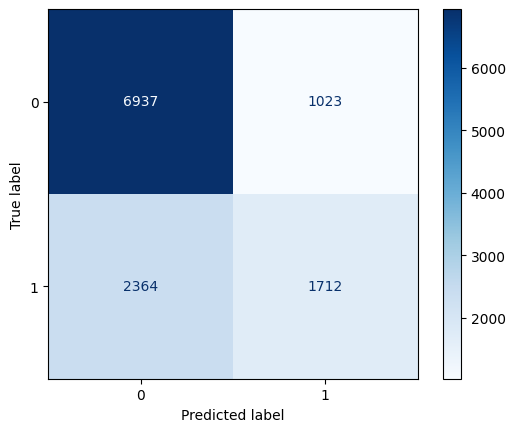

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=trained_model.classes_)
disp.plot(cmap='Blues')


In [39]:
# Save the DataFrame as a new "table"
output_path = '/content/Prediction_Results.csv'
df.to_csv(output_path, index=False)

print(f"Prediction results saved to {output_path}")


Prediction results saved to /content/Prediction_Results.csv


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define true labels and predicted labels
y_true = df['Exited']
y_pred = df['predicted_Exited']
y_probs = df['predicted_Exited_probs']

# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_probs)

# Print the results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")


Accuracy: 0.72
Precision: 0.63
Recall: 0.42
F1 Score: 0.50
ROC AUC: 0.73


In [41]:
# Save predictions to a new CSV file
output_path = '/content/Prediction_Evaluation_Results.csv'
df.to_csv(output_path, index=False)

print(f"Prediction results saved to {output_path}")


Prediction results saved to /content/Prediction_Evaluation_Results.csv
